In [163]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import cv2
import pandas as pd
import seaborn as sns
from skimage.measure import regionprops, label
from scipy.signal import savgol_filter
import glob

In [158]:
def order_box_points(box):
    s = box.sum(axis=1)
    diff = np.diff(box, axis=1).flatten()
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = box[np.argmin(s)]      # top-left
    ordered[2] = box[np.argmax(s)]      # bottom-right
    ordered[1] = box[np.argmin(diff)]   # top-right
    ordered[3] = box[np.argmax(diff)]   # bottom-left
    return ordered

In [165]:
tifs = glob.glob(r"z:\Bel\Farid\Paired_Dextran_Images\vm_outputs\*8channel.tif")
print(len(tifs))
test = tifffile.imread(Path(tifs[1]))

96


In [166]:
dextran = test[:,2,:,:]
full_segmentation = test[:,-4,:,:]
valid_region = test[:,3,:,:]
valid_dextran = dextran * (valid_region>0) * (full_segmentation>0)
chip_2d = np.max(valid_region, axis=0)
flat_dextran = np.sum(valid_dextran, axis=0)
contours, _ = cv2.findContours((chip_2d>0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)
rect = cv2.minAreaRect(largest)  # ((cx, cy), (w, h), angle)
box = cv2.boxPoints(rect)        # 4 corner points, already correctly ordered
object_height = int(rect[1][1])
object_width = int(rect[1][0])

In [167]:
src = order_box_points(box)
dst = np.array([
    [0, 0],
    [object_width-1, 0],
    [object_width-1, object_height-1],
    [0, object_height-1]
], dtype=np.float32)

M = cv2.getPerspectiveTransform(src, dst)

In [168]:
img_rectified = cv2.warpPerspective(
    flat_dextran.astype(np.float32),
    M,
    (object_width, object_height),
    flags=cv2.INTER_LINEAR
)

mask_rectified = cv2.warpPerspective(
    chip_2d,
    M,
    (object_width, object_height),
    flags=cv2.INTER_NEAREST
).astype(bool)

# Only include pixels belonging to original label
img_masked = np.where(mask_rectified, img_rectified, 0)

# Sum left -> right for every y
sums = img_masked.sum(axis=1)
ys = np.arange(sums.shape[0])
profile = pd.DataFrame({"y": ys, "intensity": sums})

<Axes: xlabel='y', ylabel='intensity'>

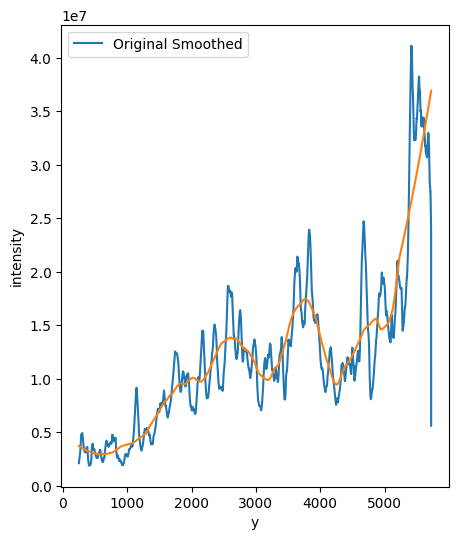

In [169]:
smoothed = (
    profile
    .rolling(window=500, on="intensity")
    .mean(numeric_only=True)
    .reset_index()
)
smoothed = smoothed[smoothed["y"]>0]

fig, ax = plt.subplots( figsize=(5,6))
sns.lineplot(data=smoothed, x="y", y="intensity", ax=ax, label='Original Smoothed')
smoothed["intensity_savgol"] = savgol_filter(smoothed["intensity"], window_length=1000, polyorder=2)
sns.lineplot(data=smoothed, x="y", y="intensity_savgol", ax=ax)


In [177]:
from scipy.signal import find_peaks, peak_widths
signal = smoothed["intensity_savgol"].to_numpy()
y=smoothed["y"].to_numpy()
peaks, properties = find_peaks(signal, prominence=5, distance=5)

In [179]:
print(signal[peaks])

[ 9561885. 10096407. 13865758. 13761503. 17452256. 15601167.]


In [175]:
print(len(peaks), y[peaks], signal[peaks])

IndexError: index 1590 is out of bounds for axis 0 with size 8

In [ ]:
from vtkmodules.vtkFiltersGeneral import (
    vtkDiscreteFlyingEdges3D,
    vtkDiscreteMarchingCubes
)


In [46]:
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk, vtk_to_numpy
import napari


seg = (full_segmentation > 0).astype(np.uint8)

# ------------------------------------------------------------
# NumPy -> vtkImageData
# ------------------------------------------------------------

z, y, x = seg.shape

vtk_image = vtk.vtkImageData()
vtk_image.SetDimensions(x, y, z)

# VTK coordinates are X, Y, Z
# Your napari scale is Z, Y, X = (10, 2, 2)
vtk_image.SetSpacing(2, 2, 10)

vtk_array = numpy_to_vtk(
    seg.ravel(order="C"),
    deep=True,
    array_type=vtk.VTK_UNSIGNED_CHAR,
)

vtk_image.GetPointData().SetScalars(vtk_array)


# ------------------------------------------------------------
# Surface Nets
# ------------------------------------------------------------

surface_nets = vtk.vtkSurfaceNets3D()
surface_nets.SetInputData(vtk_image)

# Extract label 1
surface_nets.SetValue(0, 1)

# Built-in smoothing
surface_nets.SetSmoothing(True)
surface_nets.SetNumberOfIterations(500)

# Napari needs triangles
surface_nets.SetOutputMeshTypeToTriangles()

surface_nets.Update()

mesh = surface_nets.GetOutput()


# ------------------------------------------------------------
# VTK mesh -> NumPy
# ------------------------------------------------------------

# VTK vertices are X, Y, Z
vertices_xyz = vtk_to_numpy(mesh.GetPoints().GetData())

# Napari volume coordinates are Z, Y, X
vertices = vertices_xyz[:, [2, 1, 0]]

# vtkCellArray format:
# [3, i0, i1, i2,
#  3, i0, i1, i2,
#  ...]
polys = vtk_to_numpy(mesh.GetPolys().GetData())
faces = polys.reshape(-1, 4)[:, 1:]


# ------------------------------------------------------------
# Napari
# ------------------------------------------------------------

viewer = napari.Viewer()

viewer.add_labels(
    full_segmentation.astype(np.uint8),
    scale=(10, 2, 2),
    name="segmentation",
)

viewer.add_surface(
    (vertices, faces),
    name="smoothed surface",
    shading="smooth",
)

C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_1528\57995078.py:67: DeprecationWarning: Call to deprecated method GetData. (Use ExportLegacyFormat, or GetOffsetsArray/GetConnectivityArray instead.) -- Deprecated since version 9.6.0.
  polys = vtk_to_numpy(mesh.GetPolys().GetData())


<Surface layer 'smoothed surface' at 0x1c4f9e70dc0>

In [43]:
faces


array([[  217924,        1,   217925],
       [       1,   217924,        0],
       [  217925,        2,   217926],
       ...,
       [12699796, 12715537, 12699797],
       [12715537, 12699744, 12699797],
       [12699744, 12715537, 12715534]], shape=(25197430, 3))

In [ ]:
import napari
viewer = napari.Viewer()
viewer.add_labels(full_segmentation.astype(np.uint8), scale =(10,2,2))

c:\Users\taylorhearn\AppData\Local\miniconda3\envs\cellpose_napari\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


<Labels layer 'Labels' at 0x1c1a32546d0>